# ORDER BY Parallel Sort Performance Report

This notebook loads `ORDER_BY_PARALLEL_SORT_RESULTS.json`, pairs parallel and serial runs, and highlights where the parallel sort buffer wins or loses.

In [2]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

# RESULTS = Path('ORDER_BY_PARALLEL_SORT_RESULTS.json')
RESULTS = Path('/tmp/order_by_parallel_sort_smoke.json')
with RESULTS.open() as f:
    raw = json.load(f)['results']

df = pd.DataFrame(raw)
for col in ['elapsedUs', 'cpuUs', 'sortColToRowTimeUs', 'sortInSortTimeUs', 'sortOutputTimeUs', 'mergePlanningTimeUs', 'mergeExecutionTimeUs']:
    if col in df:
        df[col.replace('Us', 'Ms')] = df[col] / 1000.0
df['dataGB'] = df['dataBytes'] / (1024 ** 3)
df['memoryGB'] = df['memoryBytes'] / (1024 ** 3)
df.head()

,name,parallel,parallelThreads,keyShape,numKeys,numPayloadFields,inputRows,outputRows,dataBytes,inputBytes,...,mergeExecutionTimeUs,elapsedMs,cpuMs,sortColToRowTimeMs,sortInSortTimeMs,sortOutputTimeMs,mergePlanningTimeMs,mergeExecutionTimeMs,dataGB,memoryGB
0,parallel_on_data64MB_mem128MB_all_int_1keys_2p...,True,1,all_int,1,2,131072,131072,67108864,67108864,...,71318,181.321,182.317,10.512,60.055,72.092,0.006,71.318,0.0625,0.125
1,parallel_on_data64MB_mem128MB_mixed_1keys_2pay...,True,1,mixed,1,2,131072,131072,67108864,67108864,...,71016,172.956,173.846,9.067,56.546,71.752,0.017,71.016,0.0625,0.125
2,parallel_off_data64MB_mem128MB_all_int_1keys_2...,False,1,all_int,1,2,131072,131072,67108864,67108864,...,0,108.888,108.892,4.618,49.052,15.961,0.000,0.000,0.0625,0.125
3,parallel_off_data64MB_mem128MB_mixed_1keys_2pa...,False,1,mixed,1,2,131072,131072,67108864,67108864,...,0,114.402,114.407,4.255,52.657,19.295,0.000,0.000,0.0625,0.125
4,parallel_on_data64MB_mem128MB_all_int_1keys_2p...,True,4,all_int,1,2,131072,131072,67108864,67108864,...,78130,142.940,180.009,9.281,56.649,42.967,0.012,78.130,0.0625,0.125


In [3]:
keys = ['parallelThreads', 'keyShape', 'numKeys', 'numPayloadFields', 'dataBytes', 'memoryBytes']
parallel = df[df['parallel']].copy()
serial = df[~df['parallel']].copy()
paired = parallel.merge(serial, on=keys, suffixes=('_parallel', '_serial'))
paired['speedup'] = paired['elapsedUs_serial'] / paired['elapsedUs_parallel']
paired['elapsedDeltaMs'] = (paired['elapsedUs_parallel'] - paired['elapsedUs_serial']) / 1000.0
paired['status'] = paired['speedup'].map(lambda x: 'parallel faster' if x > 1.0 else ('tie' if abs(x - 1.0) < 0.01 else 'serial faster'))
paired['dataGB'] = paired['dataBytes'] / (1024 ** 3)
paired['memoryGB'] = paired['memoryBytes'] / (1024 ** 3)
paired.sort_values('speedup').head(20)[keys + ['dataGB', 'memoryGB', 'speedup', 'elapsedDeltaMs', 'status']]

,parallelThreads,keyShape,numKeys,numPayloadFields,dataBytes,memoryBytes,dataGB,memoryGB,speedup,elapsedDeltaMs,status
0,1,all_int,1,2,67108864,134217728,0.0625,0.125,0.600526,72.433,serial faster
1,1,mixed,1,2,67108864,134217728,0.0625,0.125,0.661451,58.554,serial faster
2,4,all_int,1,2,67108864,134217728,0.0625,0.125,0.758220,34.560,serial faster
3,4,mixed,1,2,67108864,134217728,0.0625,0.125,0.775518,30.172,serial faster


## Worst regressions and best wins

In [4]:
display(paired.sort_values('speedup').head(20)[keys + ['dataGB', 'memoryGB', 'elapsedUs_parallel', 'elapsedUs_serial', 'speedup', 'elapsedDeltaMs', 'spillRuns_parallel', 'spillRuns_serial', 'mergeTasks_parallel', 'mergePlanningTimeUs_parallel']])
display(paired.sort_values('speedup', ascending=False).head(20)[keys + ['dataGB', 'memoryGB', 'elapsedUs_parallel', 'elapsedUs_serial', 'speedup', 'elapsedDeltaMs', 'spillRuns_parallel', 'spillRuns_serial', 'mergeTasks_parallel', 'mergePlanningTimeUs_parallel']])

,parallelThreads,keyShape,numKeys,numPayloadFields,dataBytes,memoryBytes,dataGB,memoryGB,elapsedUs_parallel,elapsedUs_serial,speedup,elapsedDeltaMs,spillRuns_parallel,spillRuns_serial,mergeTasks_parallel,mergePlanningTimeUs_parallel
0,1,all_int,1,2,67108864,134217728,0.0625,0.125,181321,108888,0.600526,72.433,0,0,2,6
1,1,mixed,1,2,67108864,134217728,0.0625,0.125,172956,114402,0.661451,58.554,0,0,2,17
2,4,all_int,1,2,67108864,134217728,0.0625,0.125,142940,108380,0.758220,34.560,0,0,2,12
3,4,mixed,1,2,67108864,134217728,0.0625,0.125,134407,104235,0.775518,30.172,0,0,2,7


,parallelThreads,keyShape,numKeys,numPayloadFields,dataBytes,memoryBytes,dataGB,memoryGB,elapsedUs_parallel,elapsedUs_serial,speedup,elapsedDeltaMs,spillRuns_parallel,spillRuns_serial,mergeTasks_parallel,mergePlanningTimeUs_parallel
3,4,mixed,1,2,67108864,134217728,0.0625,0.125,134407,104235,0.775518,30.172,0,0,2,7
2,4,all_int,1,2,67108864,134217728,0.0625,0.125,142940,108380,0.758220,34.560,0,0,2,12
1,1,mixed,1,2,67108864,134217728,0.0625,0.125,172956,114402,0.661451,58.554,0,0,2,17
0,1,all_int,1,2,67108864,134217728,0.0625,0.125,181321,108888,0.600526,72.433,0,0,2,6


## Speedup heatmaps

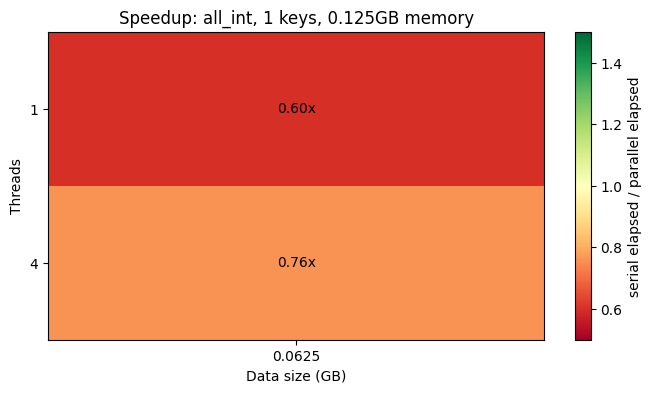

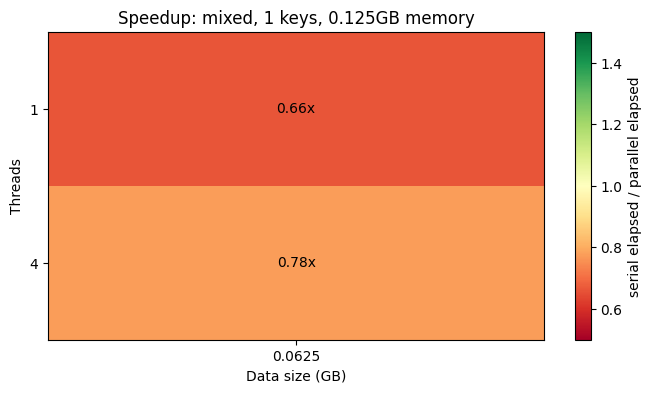

/tmp/ipykernel_2230114/2522120092.py:5: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  im = ax.imshow(pivot, aspect='auto', cmap='RdYlGn', vmin=0.5, vmax=1.5)
/tmp/ipykernel_2230114/2522120092.py:5: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  im = ax.imshow(pivot, aspect='auto', cmap='RdYlGn', vmin=0.5, vmax=1.5)


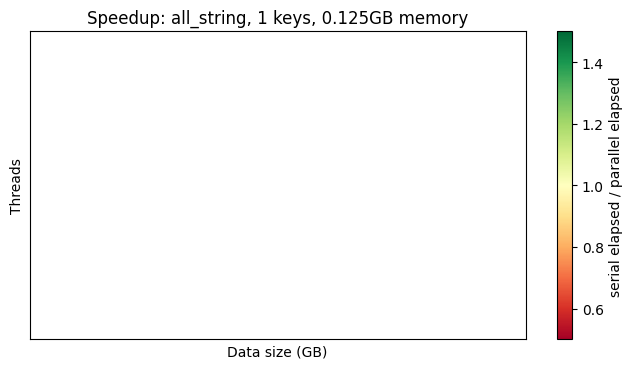

In [5]:
def heatmap_for(key_shape, num_keys, memory_gb):
    subset = paired[(paired['keyShape'] == key_shape) & (paired['numKeys'] == num_keys) & (paired['memoryGB'] == memory_gb)]
    pivot = subset.pivot_table(index='parallelThreads', columns='dataGB', values='speedup', aggfunc='mean')
    fig, ax = plt.subplots(figsize=(8, 4))
    im = ax.imshow(pivot, aspect='auto', cmap='RdYlGn', vmin=0.5, vmax=1.5)
    ax.set_xticks(range(len(pivot.columns)), [str(x) for x in pivot.columns])
    ax.set_yticks(range(len(pivot.index)), [str(x) for x in pivot.index])
    ax.set_xlabel('Data size (GB)')
    ax.set_ylabel('Threads')
    ax.set_title(f'Speedup: {key_shape}, {num_keys} keys, {memory_gb:g}GB memory')
    for i, thread in enumerate(pivot.index):
        for j, data_gb in enumerate(pivot.columns):
            val = pivot.loc[thread, data_gb]
            if pd.notna(val):
                ax.text(j, i, f'{val:.2f}x', ha='center', va='center', color='black')
    fig.colorbar(im, ax=ax, label='serial elapsed / parallel elapsed')
    plt.show()

for memory_gb in sorted(paired['memoryGB'].unique()):
    for key_shape in ['all_int', 'mixed', 'all_string']:
        for num_keys in sorted(paired['numKeys'].unique()):
            heatmap_for(key_shape, num_keys, memory_gb)

## Regression correlation checks

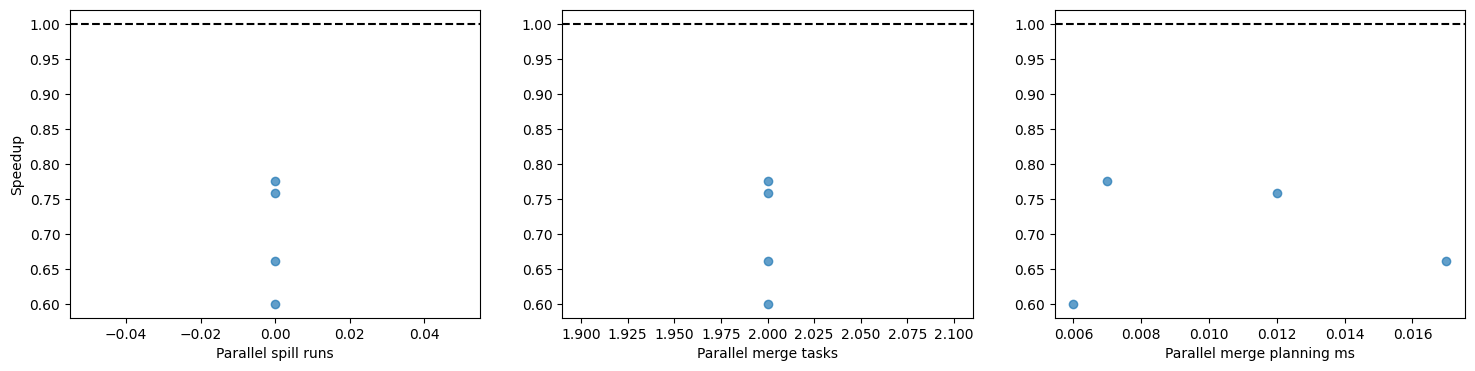

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
axes[0].scatter(paired['spillRuns_parallel'], paired['speedup'], alpha=0.7)
axes[0].set_xlabel('Parallel spill runs')
axes[0].set_ylabel('Speedup')
axes[0].axhline(1.0, color='black', linestyle='--')
axes[1].scatter(paired['mergeTasks_parallel'], paired['speedup'], alpha=0.7)
axes[1].set_xlabel('Parallel merge tasks')
axes[1].axhline(1.0, color='black', linestyle='--')
axes[2].scatter(paired['mergePlanningTimeUs_parallel'] / 1000.0, paired['speedup'], alpha=0.7)
axes[2].set_xlabel('Parallel merge planning ms')
axes[2].axhline(1.0, color='black', linestyle='--')
plt.show()

## Summary table

In [7]:
summary = paired.groupby(['parallelThreads', 'keyShape', 'numKeys', 'memoryGB']).agg(
    cases=('speedup', 'count'),
    wins=('speedup', lambda s: (s > 1.0).sum()),
    losses=('speedup', lambda s: (s < 1.0).sum()),
    mean_speedup=('speedup', 'mean'),
    min_speedup=('speedup', 'min'),
    max_speedup=('speedup', 'max'),
).reset_index()
summary.sort_values(['mean_speedup']).head(50)

,parallelThreads,keyShape,numKeys,memoryGB,cases,wins,losses,mean_speedup,min_speedup,max_speedup
0,1,all_int,1,0.125,1,0,1,0.600526,0.600526,0.600526
1,1,mixed,1,0.125,1,0,1,0.661451,0.661451,0.661451
2,4,all_int,1,0.125,1,0,1,0.758220,0.758220,0.758220
3,4,mixed,1,0.125,1,0,1,0.775518,0.775518,0.775518
